In [105]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.svm import SVC
from sklearn.metrics import *
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import *
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn import *
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from numpy import argmax
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
from yellowbrick.classifier import ROCAUC, ClassificationReport, PrecisionRecallCurve
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score

In [5]:
CS_data = pd.read_csv("https://raw.githubusercontent.com/koroteevmv/ML_course/main/ML5.3%20categorical%20features/data/Customer_support_data.csv")

In [6]:
CS_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                85907 non-null  object 
 1   channel_name             85907 non-null  object 
 2   category                 85907 non-null  object 
 3   Sub-category             85907 non-null  object 
 4   Customer Remarks         28742 non-null  object 
 5   Order_id                 67675 non-null  object 
 6   order_date_time          17214 non-null  object 
 7   Issue_reported at        85907 non-null  object 
 8   issue_responded          85907 non-null  object 
 9   Survey_response_Date     85907 non-null  object 
 10  Customer_City            17079 non-null  object 
 11  Product_category         17196 non-null  object 
 12  Item_price               17206 non-null  float64
 13  connected_handling_time  242 non-null    float64
 14  Agent_name            

In [7]:
CS_data.describe(include="all")

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
count,85907,85907,85907,85907,28742,67675,17214,85907,85907,85907,17079,17196,17206.000000,242.000000,85907,85907,85907,85907,85907,85907.000000
unique,85907,3,12,57,18231,67675,13766,30923,30262,31,1782,9,NaN,NaN,1371,40,6,5,5,NaN
top,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Inbound,Returns,Reverse Pickup Enquiry,Good,c27c9bb4-fa36-4140-9f1f-21009254ffdb,09/08/2023 11:55,15/08/2023 10:59,28/08/2023 00:00,28-Aug-23,HYDERABAD,Electronics,NaN,NaN,Wendy Taylor,Carter Park,John Smith,>90,Morning,NaN
freq,1,68142,44097,22389,1390,1,7,13,3378,3452,722,4706,NaN,NaN,429,4273,25261,30660,41426,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5660.774846,462.400826,NaN,NaN,NaN,NaN,NaN,4.242157
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12825.728411,246.295037,NaN,NaN,NaN,NaN,NaN,1.378903
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,1.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,392.000000,293.000000,NaN,NaN,NaN,NaN,NaN,4.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,979.000000,427.000000,NaN,NaN,NaN,NaN,NaN,5.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2699.750000,592.250000,NaN,NaN,NaN,NaN,NaN,5.000000


In [9]:
T_data = pd.read_csv("https://raw.githubusercontent.com/koroteevmv/ML_course/main/ML5.3%20categorical%20features/data/titanic.csv")

In [10]:
T_data.describe(exclude=[np.number])

,Pclass,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,891,204,889
unique,3,891,2,681,147,3
top,third,"Braund, Mr. Owen Harris",male,347082,B96 B98,S
freq,491,1,577,7,4,644


<Axes: xlabel='channel_name', ylabel='Count'>

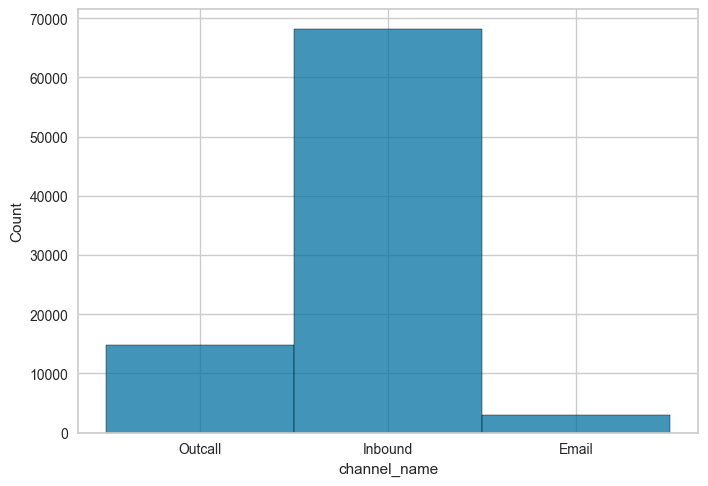

In [11]:
sns.histplot(data=CS_data, x="channel_name")

In [12]:
CS_data.channel_name.value_counts()

channel_name
Inbound    68142
Outcall    14742
Email       3023
Name: count, dtype: int64

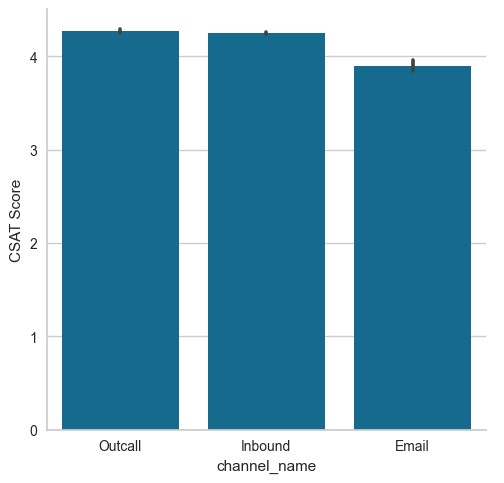

In [13]:
sns.catplot(data=CS_data, x="channel_name", y="CSAT Score", kind="bar")

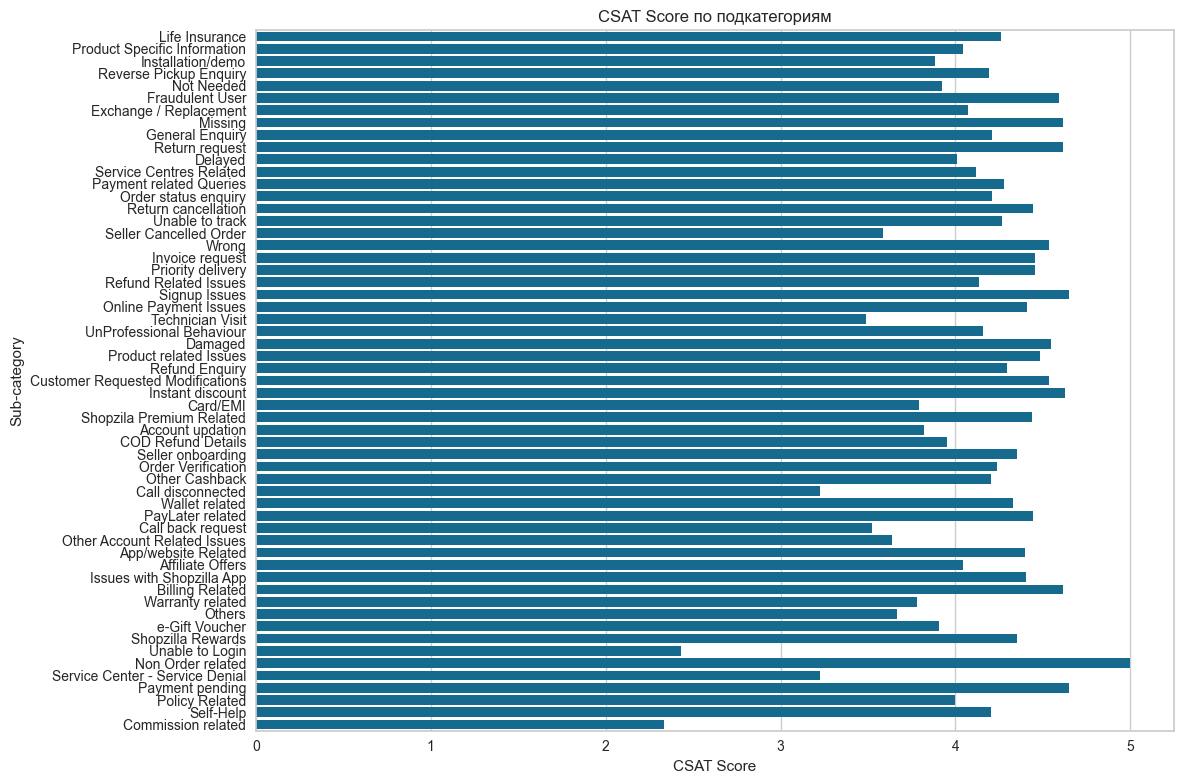

In [15]:
plt.figure(figsize=(12, 8))
sns.barplot(data=CS_data, y="Sub-category", x="CSAT Score", errorbar=None)
plt.title("CSAT Score по подкатегориям")
plt.tight_layout()
plt.show()

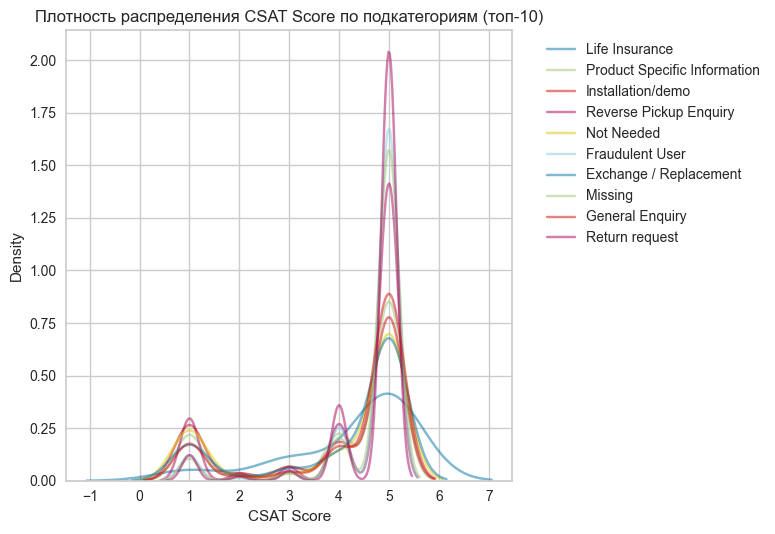

In [19]:
for category in CS_data['Sub-category'].unique()[:10]:
    subset = CS_data[CS_data['Sub-category'] == category]
    sns.kdeplot(data=subset, x="CSAT Score", label=category, alpha=0.5)
plt.title("Плотность распределения CSAT Score по подкатегориям (топ-10)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [20]:
CS_data["Customer Remarks New"] = (CS_data["Customer Remarks"].str.len() > 3).astype(int)

In [21]:
CS_data["Is_order"] = (CS_data["Order_id"].isna()).astype(int)

In [22]:
CS_data.loc[~CS_data["Sub-category"].isin([
    "Reverse Pickup Enquiry", "Return request", "Delayed", "Order status enquiry", 
    "Installation/demo", "Fraudulent User", "Product Specific Information"
    ]), "Sub-category"] = "Other"

In [23]:
CS_data.groupby(["Agent_name"]).agg({'Agent_name': 'count'})

,Agent_name
Agent_name,
Aaron Edwards,93
Aaron Romero,59
Abigail Gonzalez,25
Adam Barnett,56
Adam Hammond,60
...,...
Yesenia Bowers,50
Zachary Collins,75
Zachary Ford,62


In [24]:
CS_data['Agent_count'] = CS_data.groupby(["Agent_name"])["Agent_name"].transform('count')

In [25]:
CS_data.groupby(["Supervisor"]).agg({'Agent_name': 'nunique'})

,Agent_name
Supervisor,
Abigail Suzuki,38
Aiden Patel,41
Alexander Tanaka,15
Amelia Tanaka,19
Austin Johnson,29
Ava Wong,70
Brayden Wong,45
Carter Park,64
Charlotte Suzuki,22


In [26]:
CS_data['Sups_no_agents'] = CS_data.groupby(["Supervisor"])["Agent_name"].transform('nunique')

In [27]:
CS_data['Product_category'] = CS_data['Product_category'].fillna('unknown')

In [28]:
CS_data['connected_handling_time'] = CS_data['connected_handling_time'].fillna('0')

In [29]:
from sklearn.preprocessing import LabelEncoder
LE_sex = LabelEncoder()
T_data.Sex = LE_sex.fit_transform(T_data.Sex)

In [30]:
T_data.Pclass.replace({
    'first': 1, 'second': 2, 'third': 3
}, inplace=True)

/var/folders/9t/l2gxj7bd2vldc_4gy7jxzmph0000gn/T/ipykernel_60761/678409162.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  T_data.Pclass.replace({


In [31]:
from sklearn.preprocessing import OneHotEncoder
OH_embarked = OneHotEncoder(sparse_output=False)
OH_embarked.fit_transform(T_data[['Embarked']])

array([[0., 0., 1., 0.],
       [1., 0., 0., 0.],
       [0., 0., 1., 0.],
       ...,
       [0., 0., 1., 0.],
       [1., 0., 0., 0.],
       [0., 1., 0., 0.]], shape=(891, 4))

In [32]:
OH_embarked.get_feature_names_out(['Embarked'])

array(['Embarked_C', 'Embarked_Q', 'Embarked_S', 'Embarked_nan'],
      dtype=object)

In [33]:
dummies = pd.DataFrame(OH_embarked.fit_transform(T_data[['Embarked']]),
                       columns=OH_embarked.get_feature_names_out(['Embarked']), 
                       index = T_data.index)

In [34]:
T_dummies = pd.concat([T_data, dummies]).drop(["Embarked"], axis=1)

In [35]:
CS_dropped = CS_data.drop([
    "Unique id",
    "Sub-category",
    "Customer Remarks",
    "Customer_City", 
    "Agent_name", 
    "Supervisor",
    "Order_id",
    "order_date_time",
    "Issue_reported at",
    "issue_responded",
    "Survey_response_Date",
    "Item_price",

], axis=1)

In [36]:
CS_dummies = pd.get_dummies(CS_dropped)

In [37]:
CS_dummies.shape

(85907, 258)

## Практическая работа

### 1. Визуализация распределения признаков и совместного распределения признаков и целевой переменной на тепловой карте

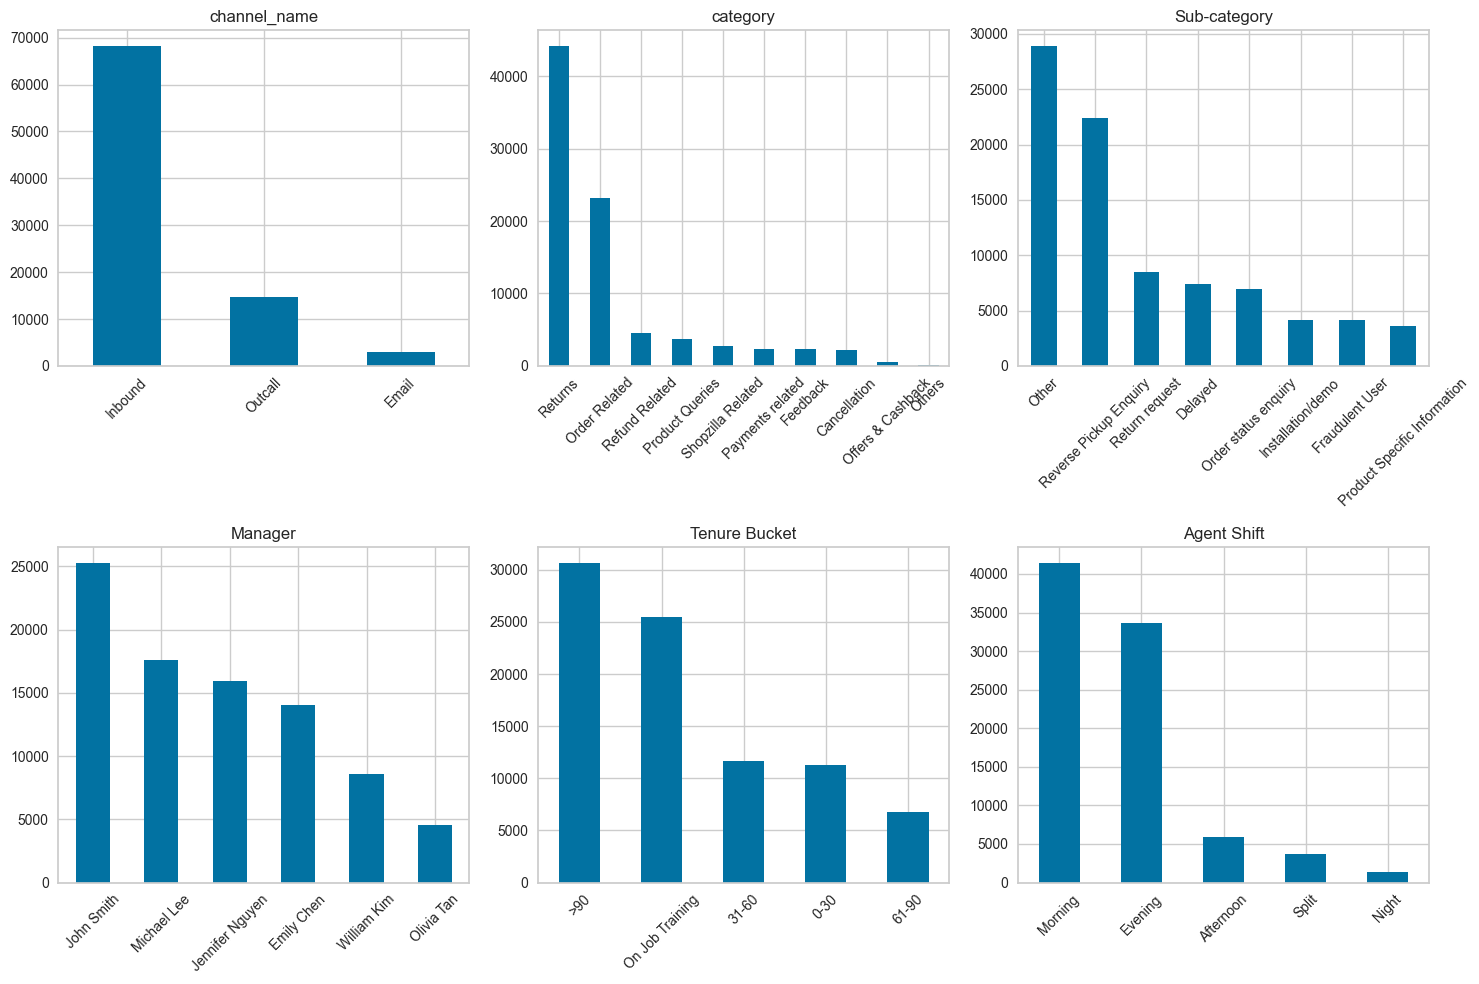

In [42]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, col in enumerate(['channel_name', 'category', 'Sub-category', 'Manager', 'Tenure Bucket', 'Agent Shift']):
    CS_data[col].value_counts().head(10).plot(kind='bar', ax=axes[idx])
    axes[idx].set_title(col)
    axes[idx].set_xlabel('')
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

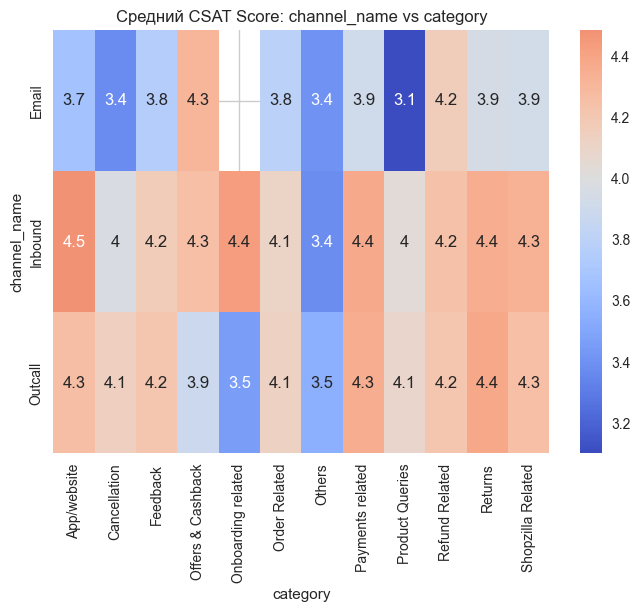

In [40]:
pivot_table = pd.pivot_table(CS_data, values='CSAT Score', 
                             index='channel_name', 
                             columns='category', 
                             aggfunc='mean')
sns.heatmap(pivot_table, annot=True, cmap='coolwarm', center=4)
plt.title('Средний CSAT Score: channel_name vs category')
plt.show()

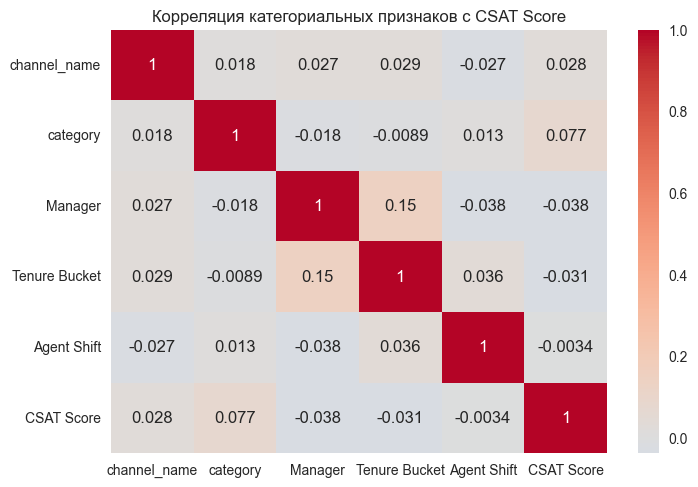

In [41]:
from sklearn.preprocessing import LabelEncoder
encoded_data = CS_data[['channel_name', 'category', 'Manager', 'Tenure Bucket', 'Agent Shift', 'CSAT Score']].copy()
for col in ['channel_name', 'category', 'Manager', 'Tenure Bucket', 'Agent Shift']:
    encoded_data[col] = LabelEncoder().fit_transform(encoded_data[col].astype(str))
sns.heatmap(encoded_data.corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Корреляция категориальных признаков с CSAT Score')
plt.show()

### 2. Дерево решений

In [44]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [45]:
X = CS_dummies.drop('CSAT Score', axis=1)
y = CS_dummies['CSAT Score']

In [46]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
dt = DecisionTreeClassifier(max_depth=10, random_state=42)
dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [47]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': dt.feature_importances_
}).sort_values('importance', ascending=False)

In [48]:
print(feature_importance.head(20))

                              feature  importance
2                         Agent_count    0.218135
3                      Sups_no_agents    0.137074
0                Customer Remarks New    0.090717
28           Product_category_unknown    0.083174
17                   category_Returns    0.059213
254               Agent Shift_Morning    0.034960
4                  channel_name_Email    0.034505
251     Tenure Bucket_On Job Training    0.023386
12             category_Order Related    0.020578
245                Manager_Olivia Tan    0.020205
1                            Is_order    0.019562
243                Manager_John Smith    0.016135
6                channel_name_Outcall    0.015843
15           category_Product Queries    0.014193
16            category_Refund Related    0.013197
27            Product_category_Mobile    0.012611
248               Tenure Bucket_31-60    0.012457
25   Product_category_Home Appliences    0.010946
26         Product_category_LifeStyle    0.010835


In [51]:
dt.score(X_test, y_test)

0.6895976409420712

Наиболее значимыми признаками оказались загруженность агента (Agent_count), количество подчиненных у руководителя (Sups_no_agents) и наличие отзыва (Customer Remarks New). Это подтверждает адекватность проведенных преобразований (агрегация, бинаризация, укрупнение категорий). Точность модели составила 0.69, что говорит о наличии значимой взаимосвязи между подготовленными признаками и целевой переменной.

### 3. Тестовая и обучающая выборки и их преобразование

In [52]:
X = CS_dropped.drop('CSAT Score', axis=1)
y = CS_dropped['CSAT Score']

In [53]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [54]:
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

In [57]:
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
for col in cat_cols:
    X_train[col] = X_train[col].astype(str)
    X_test[col] = X_test[col].astype(str)

In [58]:
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_train_encoded = ohe.fit_transform(X_train[cat_cols])
X_test_encoded = ohe.transform(X_test[cat_cols])

In [59]:
X_train_ohe = pd.DataFrame(X_train_encoded, columns=ohe.get_feature_names_out(cat_cols), index=X_train.index)
X_test_ohe = pd.DataFrame(X_test_encoded, columns=ohe.get_feature_names_out(cat_cols), index=X_test.index)

In [60]:
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
X_train_final = pd.concat([X_train_ohe, X_train[num_cols]], axis=1)
X_test_final = pd.concat([X_test_ohe, X_test[num_cols]], axis=1)

In [62]:
print(f"Обучающая: {X_train_final.shape}, Тестовая: {X_test_final.shape}")

Обучающая: (60134, 206), Тестовая: (25773, 206)


### 4. Датасет Титаник

In [64]:
T_data = pd.read_csv("https://raw.githubusercontent.com/koroteevmv/ML_course/main/ML5.3%20categorical%20features/data/titanic.csv")

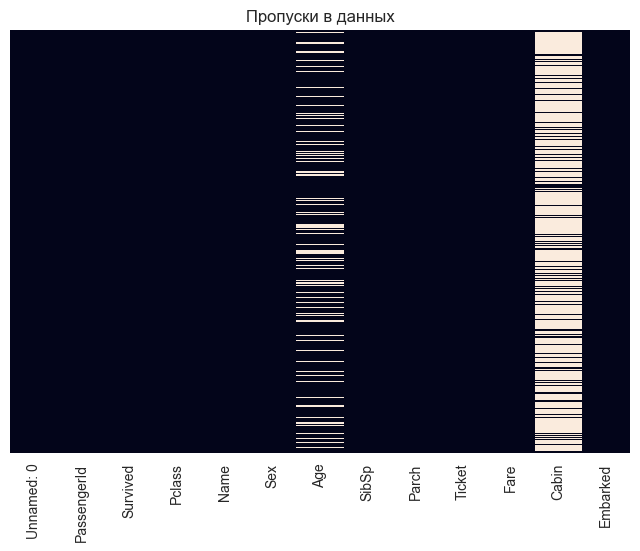

In [67]:
sns.heatmap(T_data.isnull(), yticklabels=False, cbar=False)
plt.title('Пропуски в данных')
plt.show()

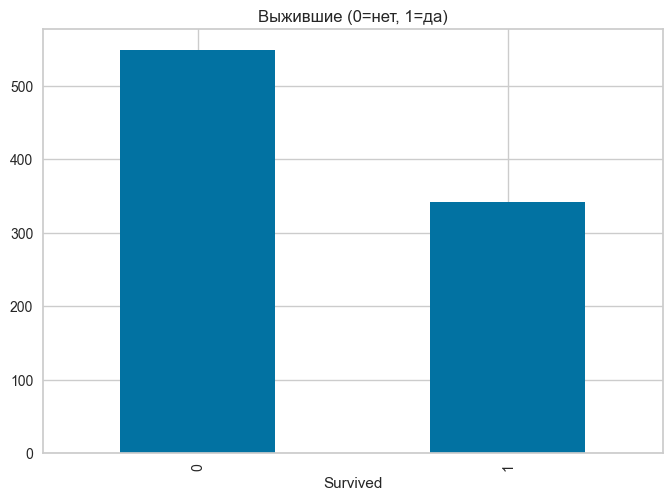

In [71]:
T_data['Survived'].value_counts().plot(kind='bar')
plt.title('Выжившие (0=нет, 1=да)')
plt.show()

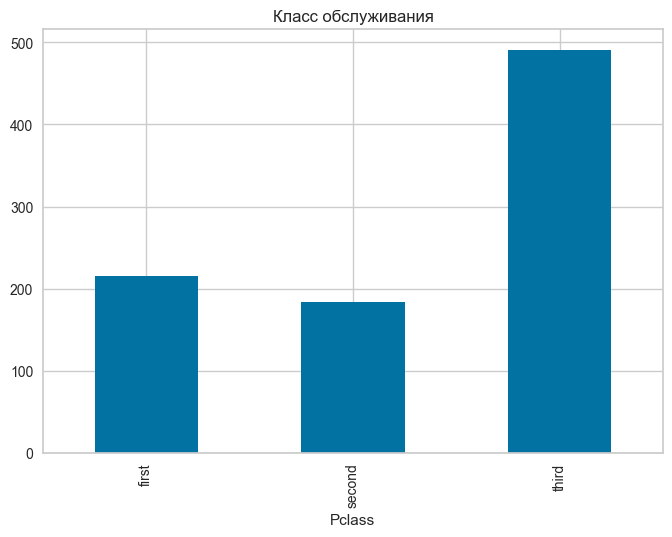

In [70]:
T_data['Pclass'].value_counts().sort_index().plot(kind='bar')
plt.title('Класс обслуживания')
plt.show()

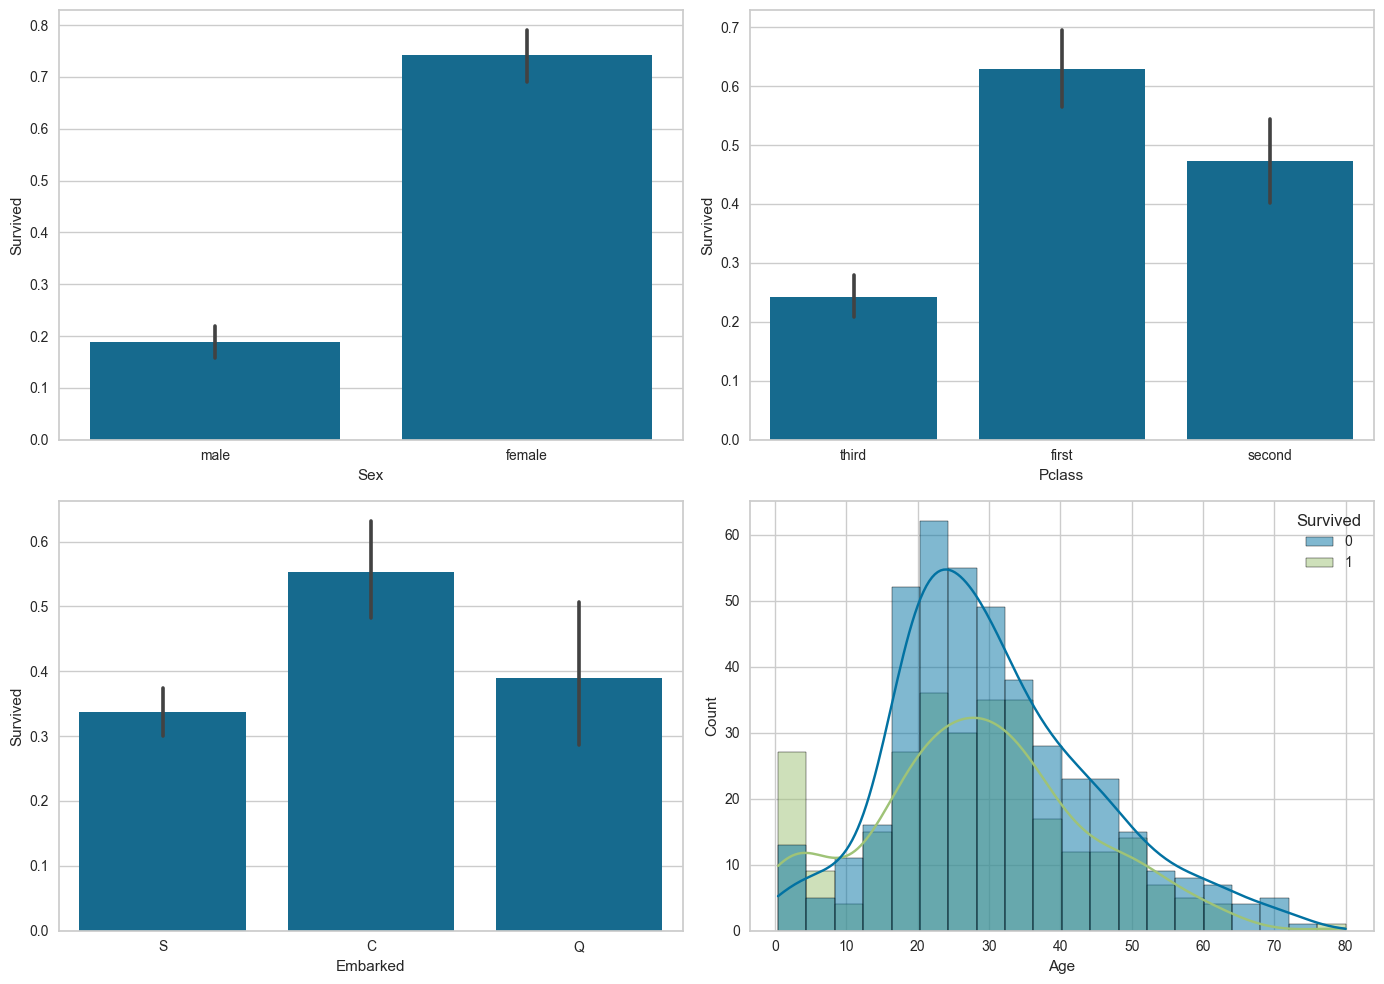

Вывод: женщины выживали чаще, 1-й класс выживал чаще, возраст влияет


In [72]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.barplot(data=T_data, x='Sex', y='Survived', ax=axes[0, 0])
sns.barplot(data=T_data, x='Pclass', y='Survived', ax=axes[0, 1])
sns.barplot(data=T_data, x='Embarked', y='Survived', ax=axes[1, 0])
sns.histplot(data=T_data, x='Age', hue='Survived', kde=True, ax=axes[1, 1])
plt.tight_layout()
plt.show()

print("Вывод: женщины выживали чаще, 1-й класс выживал чаще, возраст влияет")

In [73]:
T_data['Age'].fillna(T_data['Age'].median(), inplace=True)
T_data['Embarked'].fillna(T_data['Embarked'].mode()[0], inplace=True)
T_data.drop('Cabin', axis=1, inplace=True)

In [74]:
T_data['Sex'] = LabelEncoder().fit_transform(T_data['Sex'])

T_data = pd.get_dummies(T_data, columns=['Embarked', 'Pclass'], drop_first=True)

T_data.drop(['Name', 'Ticket', 'PassengerId'], axis=1, inplace=True)

In [75]:
X = T_data.drop('Survived', axis=1)
y = T_data['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

print(f"\nТочность: {dt.score(X_test, y_test):.4f}")


Точность: 0.8097


In [77]:
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': dt.feature_importances_
}).sort_values('importance', ascending=False)

print("\nВажность признаков:")
print(importance)


Важность признаков:
         feature  importance
1            Sex    0.511322
9   Pclass_third    0.157041
2            Age    0.112202
5           Fare    0.106172
0     Unnamed: 0    0.063242
3          SibSp    0.041458
4          Parch    0.008563
6     Embarked_Q    0.000000
7     Embarked_S    0.000000
8  Pclass_second    0.000000


### 5. Целесообразность каждого необязательного преобразования данных. проверка на точности модели

In [85]:
from sklearn.model_selection import cross_val_score

In [92]:
X = CS_dropped.drop('CSAT Score', axis=1)
y = CS_dropped['CSAT Score']

In [93]:
def test_transform(X_transformed, name):
    score = cross_val_score(DecisionTreeClassifier(max_depth=5), pd.get_dummies(X_transformed, drop_first=True), y, cv=3).mean()
    print(f"{name}: {score:.4f}")

In [94]:
test_transform(X, "Базовый")

Базовый: 0.6933


In [100]:
X_no_agg = X.drop(['Agent_count', 'Sups_no_agents'], axis=1)
test_transform(X_no_agg, "Без агрегации")

Без агрегации: 0.6937


In [101]:
X_no_remark = X.drop('Customer Remarks New', axis=1)
test_transform(X_no_remark, "Без бинаризации отзывов")

Без бинаризации отзывов: 0.6948


In [103]:
cols_to_drop = [col for col in ['category', 'Sub-category', 'Product_category'] if col in X.columns]
X_no_cat = X.drop(cols_to_drop, axis=1)
test_transform(X_no_cat, "Без категорий")

Без категорий: 0.6947


Удаление признаков не ухудшило точность модели (0.6933 → 0.6948), что указывает на их незначительное влияние или избыточность. Наиболее полезными оказались базовые категориальные признаки. Агрегация и бинаризация отзывов не дали прироста качества, что позволяет упростить датасет без потери эффективности.



### 6. Воспроизводимый код обработки датасета

In [104]:
def test_transform(X_transformed, name):
    X_enc = pd.get_dummies(X_transformed, drop_first=True)
    score = cross_val_score(DecisionTreeClassifier(max_depth=5), X_enc, y, cv=3).mean()
    print(f"{name}: {score:.4f}")